# 📊 RFM Segmentation

RFM Segmentation is a customer analysis technique used to identify and categorize customers based on their purchasing behavior. It helps businesses understand customer value and create targeted marketing strategies.

RFM stands for:

1. Recency (R)

Measures how recently a customer made a purchase.

Customers who purchased recently are more likely to buy again.

Lower recency value indicates higher customer engagement.

2. Frequency (F)

Measures how often a customer makes purchases within a given time period.

Customers who purchase frequently are considered loyal customers.

3. Monetary (M)

Measures how much money a customer spends.

Customers with higher spending contribute more revenue to the business.

🎯 Purpose of RFM Segmentation

RFM analysis helps businesses to:

Identify high-value customers

Detect loyal and inactive customers

Improve customer retention strategies

Perform targeted marketing campaigns

Predict customer behavior

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load The Dataset

In [16]:
df=pd.read_csv('/Users/tuhinalambijoy/Downloads/datacsv.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# 1 Finding Recency

In [18]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
current_date=pd.to_datetime('2012-01-01')

Let's find the last time that a customer buy something, how to find ? 


In [19]:
last_time_buy=df.groupby(['CustomerID']).max()[['InvoiceDate']]
last_time_buy

,InvoiceDate
CustomerID,
12346.0,2011-01-18 10:17:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00
...,...
18280.0,2011-03-07 09:52:00
18281.0,2011-06-12 10:53:00
18282.0,2011-12-02 11:43:00


In [20]:
(current_date-last_time_buy['InvoiceDate']).dt.days

CustomerID
12346.0    347
12347.0     24
12348.0     97
12349.0     40
12350.0    332
          ... 
18280.0    299
18281.0    202
18282.0     29
18283.0     25
18287.0     64
Name: InvoiceDate, Length: 4372, dtype: int64

In [21]:
last_time_buy['recency']=(current_date-last_time_buy['InvoiceDate']).dt.days


In [22]:
last_time_buy

,InvoiceDate,recency
CustomerID,,
12346.0,2011-01-18 10:17:00,347
12347.0,2011-12-07 15:52:00,24
12348.0,2011-09-25 13:13:00,97
12349.0,2011-11-21 09:51:00,40
12350.0,2011-02-02 16:01:00,332
...,...,...
18280.0,2011-03-07 09:52:00,299
18281.0,2011-06-12 10:53:00,202
18282.0,2011-12-02 11:43:00,29


In [23]:
recency=last_time_buy.drop(columns='InvoiceDate')

In [24]:
recency

,recency
CustomerID,
12346.0,347
12347.0,24
12348.0,97
12349.0,40
12350.0,332
...,...
18280.0,299
18281.0,202
18282.0,29


In [25]:
# df=df.drop(columns='Recency')

# Finding Frequency

In [26]:
frequnecy=df.drop_duplicates(subset='InvoiceNo')
frequnecy

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom
25,536369,21756,BATH BUILDING BLOCK WORD,3,2010-12-01 08:35:00,5.95,13047.0,United Kingdom
...,...,...,...,...,...,...,...,...
541865,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom
541869,581585,22481,BLACK TEA TOWEL CLASSIC DESIGN,12,2011-12-09 12:31:00,0.39,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom


In [27]:
freq=frequnecy.groupby('CustomerID').count()[['InvoiceNo']]
freq

,InvoiceNo
CustomerID,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,3


# Moneytary

In [28]:
df['Total']=df['Quantity']*df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [29]:
money=df.groupby(['CustomerID'])[['Total']].sum()
money

,Total
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,176.60


In [30]:
RFM=pd.concat([recency,freq,money],axis=1)
RFM

,recency,InvoiceNo,Total
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


In [31]:
RFM.columns = ['Recency', 'Frequency', 'Monetary']
RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,347,2,0.00
12347.0,24,7,4310.00
12348.0,97,4,1797.24
12349.0,40,1,1757.55
12350.0,332,1,334.40
...,...,...,...
18280.0,299,1,180.60
18281.0,202,1,80.82
18282.0,29,3,176.60


# Scaling the data before training

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaledRFM = scaler.fit_transform(RFM)

In [33]:
scaledRFM

array([[ 2.31656788, -0.32936215, -0.23100099],
       [-0.88904975,  0.20610242,  0.29343167],
       [-0.16456032, -0.11517632, -0.01231622],
       ...,
       [-0.83942719, -0.22226923, -0.20951263],
       [-0.87912524,  1.16993863,  0.02390005],
       [-0.49206924, -0.22226923, -0.00744423]], shape=(4372, 3))

In [34]:
from sklearn.cluster import KMeans

In [35]:
K_range=range(1,10)
SSE=[]
for k in K_range:
    KM=KMeans(n_clusters=k)
    KM.fit(scaledRFM)
    SSE.append(KM.inertia_)


In [36]:
SSE

[13116.0,
 9424.354643554996,
 5530.954070537202,
 4046.639585692467,
 3071.669912552643,
 2369.9971591014773,
 1924.410935159485,
 1863.442465853017,
 1414.6001196736797]

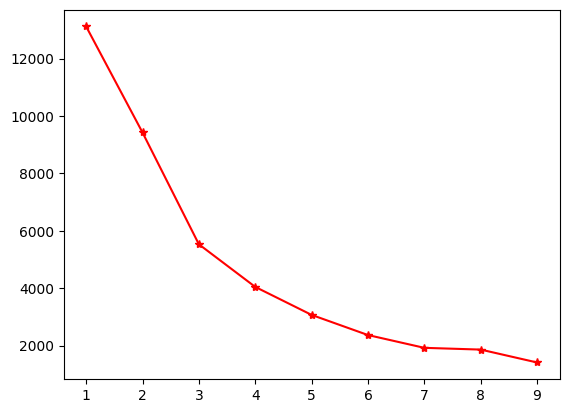

In [37]:
plt.plot(K_range,SSE,'r-*')
plt.xlabel='K'
plt.ylabel="Sum Squered Error"

In [38]:
! pip install yellowbrick

In [39]:
KMeans=KMeans(n_clusters=5)
KMeans.fit(scaledRFM)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [40]:
KMeans.labels_

array([1, 0, 0, ..., 0, 3, 0], shape=(4372,), dtype=int32)

In [41]:
RFM['Clusters']=(KMeans.labels_)
RFM

,Recency,Frequency,Monetary,Clusters
CustomerID,,,,
12346.0,347,2,0.00,1
12347.0,24,7,4310.00,0
12348.0,97,4,1797.24,0
12349.0,40,1,1757.55,0
12350.0,332,1,334.40,1
...,...,...,...,...
18280.0,299,1,180.60,1
18281.0,202,1,80.82,1
18282.0,29,3,176.60,0


In [50]:
RFM['Clusters'].value_counts()

Clusters
0    2904
1    1070
3     372
4      22
2       4
Name: count, dtype: int64

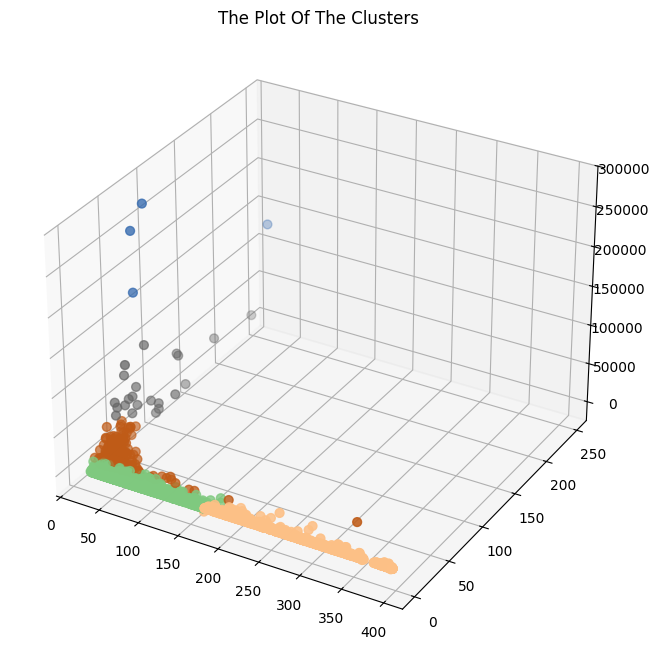

In [43]:
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
#ax.scatter(RFM["Recency"],RFM["Frequency"],RFM["Monetary"], s=40, marker='o', cmap = "Accent")
ax.scatter(RFM["Recency"],RFM["Frequency"],RFM["Monetary"], s=40, c=RFM["Clusters"], marker='o', cmap = "Accent")
ax.set_title("The Plot Of The Clusters")
plt.show()

In [44]:
rfmsegmentation=RFM.groupby(['Clusters']).mean()[["Recency","Frequency","Monetary"]]
rfmsegmentation


,Recency,Frequency,Monetary
Clusters,,,
0,66.160124,3.736915,1128.660821
1,271.142056,1.803738,454.743992
2,24.500000,110.500000,213995.575000
3,36.599462,19.465054,6883.689919
4,27.863636,78.409091,50870.171364


In [45]:
def func(row):
    if row["Clusters"]==2:
        return 'Diamond'
    elif row["Clusters"]==4:
        return 'Gold'
    elif row["Clusters"]==1:
        return 'Silver'
    else:
        return 'Others'


In [46]:
RFM['group']=RFM.apply(func, axis=1)

In [47]:
RFM

,Recency,Frequency,Monetary,Clusters,group
CustomerID,,,,,
12346.0,347,2,0.00,1,Silver
12347.0,24,7,4310.00,0,Others
12348.0,97,4,1797.24,0,Others
12349.0,40,1,1757.55,0,Others
12350.0,332,1,334.40,1,Silver
...,...,...,...,...,...
18280.0,299,1,180.60,1,Silver
18281.0,202,1,80.82,1,Silver
18282.0,29,3,176.60,0,Others


In [48]:
result = pd.DataFrame(RFM.group.value_counts())
result

,count
group,
Others,3276
Silver,1070
Gold,22
Diamond,4


In [51]:
RFM[RFM['group']=='Diamond']

,Recency,Frequency,Monetary,Clusters,group
CustomerID,,,,,
14646.0,23,77,279489.02,2,Diamond
14911.0,23,248,132572.62,2,Diamond
17450.0,30,55,187482.17,2,Diamond
18102.0,22,62,256438.49,2,Diamond


In [53]:
df[df['CustomerID']==14646.0][['Description']].count()

Description    2085
dtype: int64